Station metadata:
  station                                       station_name  latitude  \
0   42002         WEST GULF - 207 NM East of Brownsville, TX   25.9500   
1   42012              ORANGE BEACH - 44 NM SE of Mobile, AL   30.0600   
2   42019         FREEPORT, TX - 60 NM South of Freeport, TX   27.7915   
3   42020  CORPUS CHRISTI, TX - 60NM SSE of Corpus Christ...   26.9700   
4   42036              WEST TAMPA  - 112 NM WNW of Tampa, FL   28.5000   
5   42040  LUKE OFFSHORE TEST PLATFORM - 63 NM South of D...   29.2070   
6   42097                             Pulley Ridge, FL (226)   25.7040   
7   42098                  Egmont Channel Entrance, FL (214)   27.5900   

   longitude  site_elevation_m  water_depth_m  
0   -93.7800               0.0            NaN  
1   -87.5480               0.0            NaN  
2   -96.7796               0.0            NaN  
3   -96.6790               0.0            NaN  
4   -84.5050               0.0            NaN  
5   -88.2370               

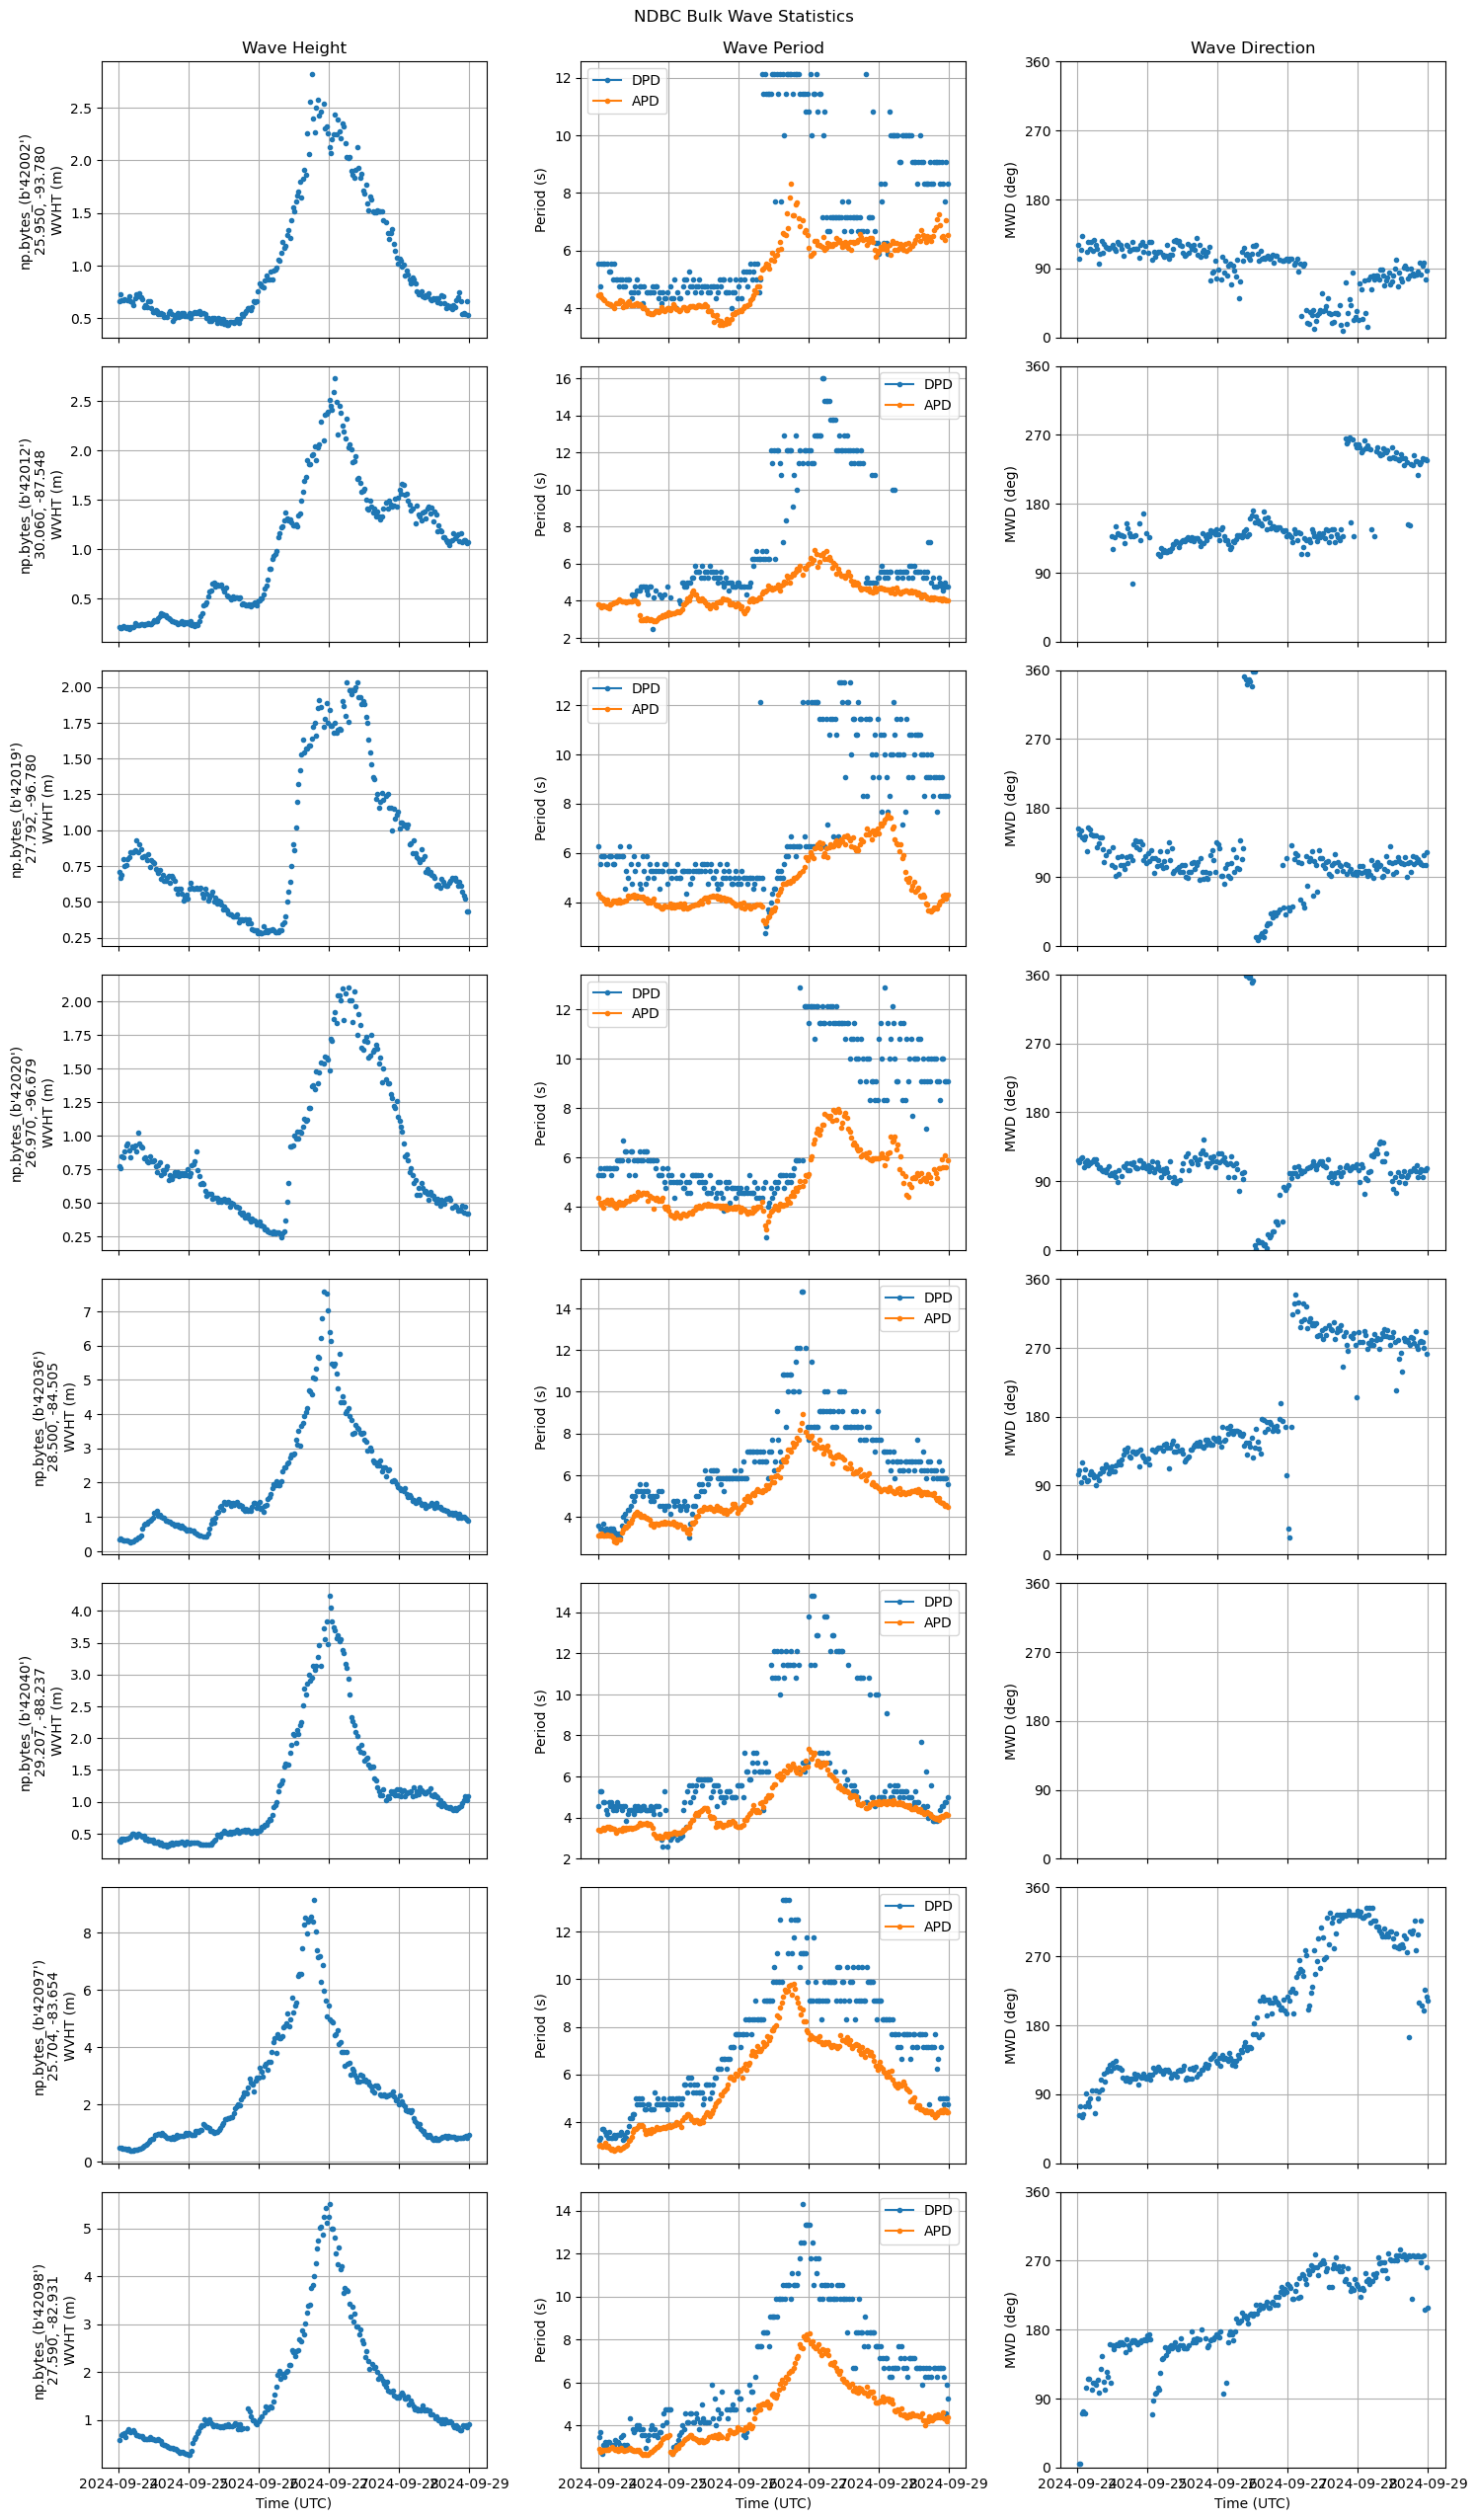

In [1]:
import io
import gzip
import re
import requests
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET


# ============================================================
# USER SETTINGS
# ============================================================

BUOYS = [
    "42002",
    "42012",
    "42019",
    "42020",
    "42036",
    "42040",
    "42097",
    "42098",
]

START = "2024-09-24"
END   = "2024-09-28"
YEAR  = 2024

OUT_NC = "ndbc_20240924_20240928.nc"


# ============================================================
# NDBC DOWNLOAD / PARSE
# ============================================================

NA_VALUES = ["MM", "999", "999.0", "9999", "99.0", "99.00", "99999", "999999"]


def _parse_ndbc_stdmet_text(text):
    """
    Parse one NDBC historical stdmet text file into a DataFrame.
    """
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    if not lines:
        raise ValueError("Empty file")

    header_line = lines[0].lstrip("#").strip()
    cols = header_line.split()

    data_start = 1
    if len(lines) > 1:
        second = lines[1].split()
        nonnumeric = 0
        for tok in second:
            try:
                float(tok)
            except Exception:
                nonnumeric += 1
        if len(second) == len(cols) and nonnumeric >= max(3, len(second) // 3):
            data_start = 2

    data_text = "\n".join(lines[data_start:])
    if not data_text.strip():
        return pd.DataFrame(columns=cols)

    df = pd.read_csv(
        io.StringIO(data_text),
        sep=r"\s+",
        names=cols,
        na_values=NA_VALUES,
        engine="python",
    )

    year_col = None
    for candidate in ["YYYY", "#YYYY", "YY", "#YY"]:
        if candidate in df.columns:
            year_col = candidate
            break
    if year_col is None:
        raise ValueError(f"Could not find year column in: {list(df.columns)}")

    required = ["MM", "DD", "hh"]
    for c in required:
        if c not in df.columns:
            raise ValueError(f"Missing required time column: {c}")

    minute_col = "mm" if "mm" in df.columns else None

    year = df[year_col].astype(int).to_numpy()
    if "YY" in year_col:
        year = np.where(year < 100, 2000 + year, year)

    month = df["MM"].astype(int).to_numpy()
    day = df["DD"].astype(int).to_numpy()
    hour = df["hh"].astype(int).to_numpy()
    minute = df[minute_col].astype(int).to_numpy() if minute_col else np.zeros(len(df), dtype=int)

    dt = pd.to_datetime(
        {
            "year": year,
            "month": month,
            "day": day,
            "hour": hour,
            "minute": minute,
        },
        errors="coerce",
        utc=True,
    )

    df.insert(0, "time", dt)
    df = df.dropna(subset=["time"]).reset_index(drop=True)
    return df


def download_ndbc_stdmet_station_year(station, year=2024, timeout=60):
    """
    Download and parse one NDBC historical stdmet file.
    """
    url = f"https://www.ndbc.noaa.gov/data/historical/stdmet/{station}h{year}.txt.gz"
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()

    with gzip.GzipFile(fileobj=io.BytesIO(r.content)) as gz:
        text = gz.read().decode("utf-8", errors="replace")

    df = _parse_ndbc_stdmet_text(text)
    df["station"] = station
    return df


def subset_date_range_inclusive(df, start, end, time_col="time"):
    """
    Inclusive UTC date filter.
    """
    start_ts = pd.Timestamp(start, tz="UTC")
    end_ts = pd.Timestamp(end, tz="UTC") + pd.Timedelta(days=1) - pd.Timedelta(microseconds=1)
    return df.loc[(df[time_col] >= start_ts) & (df[time_col] <= end_ts)].copy()


def _extract_water_depth_from_station_page(html_text):
    m = re.search(r"Water depth:\s*([0-9.]+)\s*m", html_text, flags=re.IGNORECASE)
    return float(m.group(1)) if m else np.nan


def download_ndbc_station_metadata(stations, timeout=30):
    """
    Download latitude / longitude from activestations.xml and water depth from each station page.
    Returns one row per requested station.
    """
    xml_url = "https://www.ndbc.noaa.gov/activestations.xml"
    r = requests.get(xml_url, timeout=timeout)
    r.raise_for_status()
    root = ET.fromstring(r.content)

    rows = []
    station_set = set(stations)
    xml_lookup = {}

    for st in root.findall("station"):
        sid = st.attrib.get("id")
        if sid in station_set:
            xml_lookup[sid] = {
                "station": sid,
                "station_name": st.attrib.get("name", ""),
                "latitude": float(st.attrib.get("lat")) if st.attrib.get("lat") else np.nan,
                "longitude": float(st.attrib.get("lon")) if st.attrib.get("lon") else np.nan,
                "site_elevation_m": float(st.attrib.get("elev")) if st.attrib.get("elev") else np.nan,
            }

    for sid in stations:
        row = {
            "station": sid,
            "station_name": "",
            "latitude": np.nan,
            "longitude": np.nan,
            "site_elevation_m": np.nan,
            "water_depth_m": np.nan,
        }

        if sid in xml_lookup:
            row.update(xml_lookup[sid])

        try:
            page_url = f"https://www.ndbc.noaa.gov/station_page.php?station={sid}"
            rp = requests.get(page_url, timeout=timeout)
            rp.raise_for_status()
            row["water_depth_m"] = _extract_water_depth_from_station_page(rp.text)
        except Exception as e:
            print(f"{sid}: metadata depth lookup failed -> {e}")

        rows.append(row)

    meta = pd.DataFrame(rows)
    return meta


def download_ndbc_bulk_stats(buoys, start, end, year=2024):
    """
    Download NDBC stdmet data for every buoy in the list.
    """
    per_buoy = {}

    for buoy in buoys:
        try:
            df = download_ndbc_stdmet_station_year(buoy, year=year)
            df = subset_date_range_inclusive(df, start=start, end=end)
            per_buoy[buoy] = df
            print(f"{buoy}: {len(df)} records")
        except Exception as e:
            print(f"{buoy}: FAILED -> {e}")
            per_buoy[buoy] = pd.DataFrame()

    combined = (
        pd.concat(
            [df for df in per_buoy.values() if len(df) > 0],
            ignore_index=True,
            sort=False,
        )
        if any(len(df) > 0 for df in per_buoy.values())
        else pd.DataFrame()
    )

    if len(combined) > 0:
        preferred_cols = [
            "station", "time",
            "WDIR", "WSPD", "GST", "WVHT", "DPD", "APD", "MWD",
            "PRES", "ATMP", "WTMP", "DEWP", "VIS", "PTDY", "TIDE",
        ]
        cols = [c for c in preferred_cols if c in combined.columns] + [c for c in combined.columns if c not in preferred_cols]
        combined = combined[cols].sort_values(["station", "time"]).reset_index(drop=True)

    return combined, per_buoy


# ============================================================
# SAVE TO NETCDF
# ============================================================

def build_ndbc_xarray(df, metadata, buoys):
    """
    Convert combined NDBC dataframe to xarray Dataset with dims:
      time, station

    Saves wave variables plus station metadata.
    """
    if len(df) == 0:
        raise ValueError("Input dataframe is empty")

    df = df.copy()
    metadata = metadata.copy()

    # Convert to timezone-naive datetime64[ns] for xarray/netcdf
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_convert(None)

    time = np.sort(df["time"].dropna().unique()).astype("datetime64[ns]")
    stations = [b for b in buoys if b in df["station"].unique()]
    ntime = len(time)
    nsta = len(stations)

    meta = (
        metadata.drop_duplicates(subset="station")
        .set_index("station")
        .reindex(stations)
    )

    ds = xr.Dataset(
        coords={
            "time": ("time", time),
            "station": np.arange(nsta, dtype=np.int32),
        }
    )

    # Store station_id/name as fixed-width byte strings for netCDF compatibility
    ds["station_id"] = ("station", np.asarray(stations, dtype="S8"))

    if "station_name" in meta.columns:
        ds["station_name"] = ("station", meta["station_name"].fillna("").astype("S64"))

    for name, units in [
        ("latitude", "degrees_north"),
        ("longitude", "degrees_east"),
        ("site_elevation_m", "m"),
        ("water_depth_m", "m"),
    ]:
        if name in meta.columns:
            ds[name] = ("station", meta[name].to_numpy(dtype=np.float32))
            ds[name].attrs["units"] = units

    var_map = {
        "WVHT": ("wave_height", "m"),
        "DPD":  ("dominant_period", "s"),
        "APD":  ("average_period", "s"),
        "MWD":  ("mean_wave_direction", "deg"),
    }

    time_index = pd.Index(time)
    station_index = {sta: i for i, sta in enumerate(stations)}

    for src_name, (out_name, units) in var_map.items():
        arr = np.full((ntime, nsta), np.nan, dtype=np.float32)

        if src_name in df.columns:
            for sta, g in df.groupby("station"):
                if sta not in station_index:
                    continue

                j = station_index[sta]
                gg = (
                    g[["time", src_name]]
                    .dropna()
                    .drop_duplicates(subset="time")
                    .sort_values("time")
                )

                if len(gg) == 0:
                    continue

                it = time_index.get_indexer(gg["time"].to_numpy().astype("datetime64[ns]"))
                good = it >= 0
                arr[it[good], j] = gg[src_name].to_numpy(dtype=np.float32)[good]

        ds[out_name] = (("time", "station"), arr)
        ds[out_name].attrs["units"] = units
        ds[out_name].attrs["source_name"] = src_name

    return ds


def save_ndbc_to_netcdf(df, metadata, buoys, out_nc):
    ds = build_ndbc_xarray(df, metadata, buoys)
    try:
        ds.to_netcdf(out_nc, engine="netcdf4")
    except Exception:
        ds.to_netcdf(out_nc)
    return ds


# ============================================================
# PLOTTING
# ============================================================

def stations_with_wave_data(ds):
    keep = []
    for i in range(ds.sizes["station"]):
        ok = False
        for v in ["wave_height", "dominant_period", "average_period", "mean_wave_direction"]:
            if v in ds and np.isfinite(ds[v].isel(station=i).values).any():
                ok = True
                break
        if ok:
            keep.append(i)
    return keep


def _as_str(x):
    if isinstance(x, (bytes, np.bytes_)):
        return x.decode("utf-8")
    return str(x)


def plot_ndbc_wave_multipanel(ds):
    keep = stations_with_wave_data(ds)
    if len(keep) == 0:
        raise ValueError("No buoys with wave data found in dataset")

    nrows = len(keep)
    fig, axs = plt.subplots(
        nrows=nrows,
        ncols=3,
        figsize=(15, 3.2 * nrows),
        sharex=True,
        squeeze=False,
    )

    t = ds["time"].values

    for row, i in enumerate(keep):
        sta = _as_str(ds["station_id"].isel(station=i).values)

        label_lines = [sta]

        if "latitude" in ds and "longitude" in ds:
            lat = ds["latitude"].isel(station=i).item()
            lon = ds["longitude"].isel(station=i).item()
            if np.isfinite(lat) and np.isfinite(lon):
                label_lines.append(f"{lat:.3f}, {lon:.3f}")

        if "water_depth_m" in ds:
            depth = ds["water_depth_m"].isel(station=i).item()
            if np.isfinite(depth):
                label_lines.append(f"depth={depth:.0f} m")

        row_label = "\n".join(label_lines)

        ax = axs[row, 0]
        if "wave_height" in ds:
            ax.plot(t, ds["wave_height"].isel(station=i), ".-")
        ax.set_ylabel(f"{row_label}\nWVHT (m)")
        ax.grid(True)

        ax = axs[row, 1]
        has_legend = False

        if "dominant_period" in ds:
            y = ds["dominant_period"].isel(station=i).values
            if np.isfinite(y).any():
                ax.plot(t, y, ".-", label="DPD")
                has_legend = True

        if "average_period" in ds:
            y = ds["average_period"].isel(station=i).values
            if np.isfinite(y).any():
                ax.plot(t, y, ".-", label="APD")
                has_legend = True

        ax.set_ylabel("Period (s)")
        ax.grid(True)
        if has_legend:
            ax.legend()

        ax = axs[row, 2]
        if "mean_wave_direction" in ds:
            ax.plot(t, ds["mean_wave_direction"].isel(station=i), ".-")
        ax.set_ylabel("MWD (deg)")
        ax.set_ylim(0, 360)
        ax.set_yticks([0, 90, 180, 270, 360])
        ax.grid(True)

    axs[0, 0].set_title("Wave Height")
    axs[0, 1].set_title("Wave Period")
    axs[0, 2].set_title("Wave Direction")

    for ax in axs[-1, :]:
        ax.set_xlabel("Time (UTC)")

    fig.suptitle("NDBC Bulk Wave Statistics", y=0.995)
    fig.tight_layout()
    return fig, axs


# ============================================================
# RUN: DOWNLOAD, MERGE METADATA, SAVE
# ============================================================

meta_ndbc = download_ndbc_station_metadata(BUOYS)
print("Station metadata:")
print(meta_ndbc)
print()

df_ndbc, ndbc_by_buoy = download_ndbc_bulk_stats(
    BUOYS,
    start=START,
    end=END,
    year=YEAR,
)

if len(df_ndbc):
    df_ndbc = df_ndbc.merge(meta_ndbc, on="station", how="left")

print("Record counts by station:")
print(df_ndbc.groupby("station").size() if len(df_ndbc) else "No data returned")
print()

print("Combined dataframe head:")
print(df_ndbc.head())
print()

ds_ndbc = save_ndbc_to_netcdf(df_ndbc, meta_ndbc, BUOYS, OUT_NC)
print(ds_ndbc)
print(f"\nSaved: {OUT_NC}")


# ============================================================
# RUN: READ NETCDF AND PLOT
# ============================================================

ds_plot = xr.open_dataset(OUT_NC)
fig, axs = plot_ndbc_wave_multipanel(ds_plot)
plt.show()